# Hidden Markov Models

In [15]:
pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 1.6 MB/s eta 0:00:00


In [103]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import glob


from scipy.fft import fft, fftfreq

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from hmmlearn.hmm import GaussianHMM
from sklearn.cluster import KMeans



from sklearn.metrics import confusion_matrix

## Phase 1: Data collection and preprocessing

In [1]:
import zipfile
import os

zip_path = "data.zip"      # Name of the uploaded ZIP file
extract_path = "data"       # Folder where it will be extracted

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [4]:

RAW_DIR = "data/data"
CLEAN_DIR = "data/cleaned"

os.makedirs(CLEAN_DIR, exist_ok=True)

def load_and_clean_recording(recording_path, label, file_name):
    acc_path = os.path.join(recording_path, "Accelerometer.csv")
    gyro_path = os.path.join(recording_path, "Gyroscope.csv")

    acc = pd.read_csv(acc_path)
    gyro = pd.read_csv(gyro_path)

    # Keep only needed columns
    acc = acc[["seconds_elapsed", "x", "y", "z"]]
    gyro = gyro[["seconds_elapsed", "x", "y", "z"]]

    # Rename columns for clarity
    acc = acc.rename(columns={
        "x": "acc_x",
        "y": "acc_y",
        "z": "acc_z"
    })

    gyro = gyro.rename(columns={
        "x": "gyro_x",
        "y": "gyro_y",
        "z": "gyro_z"
    })

    # Trim to 9 seconds
    acc = acc[acc["seconds_elapsed"] <= 9.0]
    gyro = gyro[gyro["seconds_elapsed"] <= 9.0]

    # Sort (important for merge_asof)
    acc = acc.sort_values("seconds_elapsed")
    gyro = gyro.sort_values("seconds_elapsed")

    # Merge using nearest timestamp alignment
    merged = pd.merge_asof(
        acc,
        gyro,
        on="seconds_elapsed",
        direction="nearest"
    )

    # Add label (important for later supervised evaluation)
    merged["label"] = label

    return merged


def process_all_data():
    all_data = []

    for label in os.listdir(RAW_DIR):
        label_path = os.path.join(RAW_DIR, label)

        if not os.path.isdir(label_path):
            continue

        for recording in os.listdir(label_path):
            recording_path = os.path.join(label_path, recording)

            if not os.path.isdir(recording_path):
                continue

            print(f"Processing: {label}/{recording}")

            try:
                cleaned = load_and_clean_recording(
                    recording_path,
                    label,
                    recording
                )

                output_path = os.path.join(
                    CLEAN_DIR,
                    f"{label}_{recording}_clean.csv"
                )

                cleaned.to_csv(output_path, index=False)

                all_data.append(cleaned)

            except Exception as e:
                print(f"Failed {label}/{recording}: {e}")

    # Optional: combine everything into one dataset
    final_dataset = pd.concat(all_data, ignore_index=True)
    final_dataset.to_csv(
        os.path.join(CLEAN_DIR, "ALL_DATA.csv"),
        index=False
    )

    print("DONE: All data processed and saved.")


In [8]:
DATA_DIR = "data"
CLEAN_DIR = "data/cleaned"

os.makedirs(CLEAN_DIR, exist_ok=True)

activities = ["standing", "walking", "jumping", "still"]

for activity in activities:

    activity_path = os.path.join(DATA_DIR, activity)

    for recording in os.listdir(activity_path):

        recording_path = os.path.join(activity_path, recording)

        if not os.path.isdir(recording_path):
            continue

        print(f"Processing {activity} -> {recording}")

        cleaned = load_and_clean_recording(
            recording_path,
            activity,
            recording
        )

        cleaned.to_csv(
            os.path.join(
                CLEAN_DIR,
                f"{activity}_{recording.replace(' ','_')}.csv"
            ),
            index=False
        )

Processing standing -> standing 3
Processing standing -> standing 10
Processing standing -> standing 6
Processing standing -> standing 12
Processing standing -> standing 7
Processing standing -> standing 8
Processing standing -> standing 11
Processing standing -> standing 5
Processing standing -> standing 9
Processing standing -> standing 4
Processing standing -> standing 2
Processing standing -> standing 1
Processing standing -> standing 13
Processing walking -> walking 5
Processing walking -> walking 11
Processing walking -> walking 2
Processing walking -> walking 7
Processing walking -> walking 6
Processing walking -> walking 4
Processing walking -> walking 1
Processing walking -> walking 12
Processing walking -> walking 13
Processing walking -> walking 8
Processing walking -> walking 3
Processing walking -> walking 9
Processing walking -> walking 10
Processing jumping -> jumping 11
Processing jumping -> jumping 1
Processing jumping -> jumping 7
Processing jumping -> jumping 10
Proc

In [9]:
# Download the cleaned data
import shutil
from google.colab import files

def download_data_folder(folder_path="data", output_zip="data_cleaned"):
    """
    Compresses a folder into a ZIP file and downloads it.

    Parameters:
        folder_path (str): Path to the folder to compress.
        output_zip (str): Name of the output ZIP file (without .zip).
    """

    # Create ZIP archive
    shutil.make_archive(output_zip, 'zip', folder_path)

    print(f"Created {output_zip}.zip")

    # Download
    files.download(f"{output_zip}.zip")


# Call the function
download_data_folder()

Created data_cleaned.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# PRINT SAMPLE RAW
acc_raw = pd.read_csv('/content/data/walking/walking 1/Accelerometer.csv')

In [11]:
# PRINT SAMPLE CLEANED
acc_clean = pd.read_csv('/content/data/cleaned/walking_walking_1.csv')

In [12]:
acc_raw

,time,seconds_elapsed,z,y,x
0,1782987622722771700,0.081772,0.382730,-1.328502,-1.126579
1,1782987622732845600,0.091845,0.797154,-1.250308,-0.686304
2,1782987622742920700,0.101921,1.158341,-1.152268,-0.363927
3,1782987622752995600,0.111996,1.311440,-1.087585,-0.232574
4,1782987622763069700,0.122070,1.225803,-1.008293,-0.142497
...,...,...,...,...,...
1014,1782987632938519300,10.297519,-0.354171,1.099696,-0.468656
1015,1782987632948594400,10.307594,-0.053748,1.112122,-0.333148
1016,1782987632958669300,10.317669,0.229141,1.126762,-0.063961
1017,1782987632968743400,10.327743,0.660462,1.101756,0.224361


In [13]:
acc_clean

,seconds_elapsed,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,label
0,0.081772,-1.126579,-1.328502,0.382730,0.263842,0.149911,-0.432686,walking
1,0.091845,-0.686304,-1.250308,0.797154,0.264348,0.062314,-0.421519,walking
2,0.101921,-0.363927,-1.152268,1.158341,0.218559,-0.028325,-0.379727,walking
3,0.111996,-0.232574,-1.087585,1.311440,0.155585,-0.073351,-0.330179,walking
4,0.122070,-0.142497,-1.008293,1.225803,0.106037,-0.075347,-0.292189,walking
...,...,...,...,...,...,...,...,...
881,8.957585,-0.168940,1.058742,-1.860317,-0.065057,0.801184,1.242100,walking
882,8.967660,0.124602,1.007809,-1.359042,0.048795,0.795364,1.216273,walking
883,8.977734,0.476733,0.956903,-0.717423,0.142898,0.717897,1.212530,walking
884,8.987809,0.769103,0.878621,-0.159200,0.211413,0.647018,1.212030,walking


## Phase 2: Feature extraction

In [17]:
# Cell 2 — Configuration

# Folder containing cleaned recordings
CLEAN_DATA_DIR = "data/cleaned"

# Output file
OUTPUT_FEATURES = "features.csv"

# Sampling information
SAMPLING_RATE = 100      # Hz

WINDOW_SIZE_SECONDS = 2

OVERLAP = 0.5

WINDOW_SIZE = int(WINDOW_SIZE_SECONDS * SAMPLING_RATE)

STEP_SIZE = int(WINDOW_SIZE * (1 - OVERLAP))

print(f"Window Size : {WINDOW_SIZE} samples")
print(f"Step Size   : {STEP_SIZE} samples")

Window Size : 200 samples
Step Size   : 100 samples


In [18]:
# Windowing
def create_windows(df, window_size, step_size):
    """
    Split one recording into overlapping windows.
    """

    windows = []

    for start in range(
            0,
            len(df) - window_size + 1,
            step_size):

        end = start + window_size

        windows.append(
            df.iloc[start:end].reset_index(drop=True)
        )

    return windows

In [19]:
# Time-Domain Features

# HELPER FUNCTIONS

#RMS
def rms(signal):

    return np.sqrt(np.mean(signal ** 2))

# Signal Magnitude Area (SMA)
def signal_magnitude_area(window):

    return (

        np.abs(window["acc_x"]).sum()

        +

        np.abs(window["acc_y"]).sum()

        +

        np.abs(window["acc_z"]).sum()

    ) / len(window)


# Time Feature Extractor
def extract_time_features(window):

  features = {}

  columns = [

      "acc_x",
      "acc_y",
      "acc_z",

      "gyro_x",
      "gyro_y",
      "gyro_z"

  ]

  for column in columns:

      signal = window[column]

      features[f"{column}_mean"] = signal.mean()

      features[f"{column}_std"] = signal.std()

      features[f"{column}_var"] = signal.var()

      features[f"{column}_rms"] = rms(signal)

      features[f"{column}_max"] = signal.max()

      features[f"{column}_min"] = signal.min()

  # Signal Magnitude Area

  features["SMA"] = signal_magnitude_area(window)

  # Correlation

  features["corr_xy"] = window["acc_x"].corr(window["acc_y"])

  features["corr_xz"] = window["acc_x"].corr(window["acc_z"])

  features["corr_yz"] = window["acc_y"].corr(window["acc_z"])

  return features



# Frequency Features
def extract_frequency_features(window):

    magnitude = np.sqrt(

        window["acc_x"]**2 +

        window["acc_y"]**2 +

        window["acc_z"]**2

    )

    fft_values = np.abs(

        fft(magnitude)

    )

    frequencies = fftfreq(

        len(magnitude),

        d=1 / SAMPLING_RATE

    )

    positive = frequencies > 0

    frequencies = frequencies[positive]

    fft_values = fft_values[positive]

    dominant_frequency = frequencies[

        np.argmax(fft_values)

    ]

    spectral_energy = np.sum(

        fft_values ** 2

    )

    peak_magnitude = np.max(

        fft_values

    )

    return {

        "dominant_frequency": dominant_frequency,

        "spectral_energy": spectral_energy,

        "fft_peak_magnitude": peak_magnitude

    }

In [20]:
def extract_features(window):

    features = {}

    features.update(

        extract_time_features(window)

    )

    features.update(

        extract_frequency_features(window)

    )

    features["label"] = window["label"].iloc[0]

    return features

In [21]:
# Process One Recording
def process_recording(file_path):

    df = pd.read_csv(file_path)

    recording_id = os.path.splitext(
        os.path.basename(file_path)
    )[0]

    windows = create_windows(
        df,
        WINDOW_SIZE,
        STEP_SIZE
    )

    rows = []

    for window_number, window in enumerate(windows, start=1):

        features = extract_features(window)

        features["recording_id"] = recording_id

        features["window_id"] = window_number

        rows.append(features)

    return rows

In [22]:
# Process Entire Dataset
all_features = []

files = sorted(

    glob.glob(

        os.path.join(

            CLEAN_DATA_DIR,

            "*.csv"

        )

    )

)

print(f"{len(files)} cleaned recordings found.")

for file in files:

    print(

        "Processing",

        os.path.basename(file)

    )

    all_features.extend(

        process_recording(file)

    )

features = pd.DataFrame(all_features)

print()

print(features.shape)

features.head()

52 cleaned recordings found.
Processing jumping_jumping_1.csv
Processing jumping_jumping_10.csv
Processing jumping_jumping_11.csv
Processing jumping_jumping_12.csv
Processing jumping_jumping_13.csv
Processing jumping_jumping_2.csv
Processing jumping_jumping_3.csv
Processing jumping_jumping_4.csv
Processing jumping_jumping_5.csv
Processing jumping_jumping_6.csv
Processing jumping_jumping_7.csv
Processing jumping_jumping_8.csv
Processing jumping_jumping_9.csv
Processing standing_standing_1.csv
Processing standing_standing_10.csv
Processing standing_standing_11.csv
Processing standing_standing_12.csv
Processing standing_standing_13.csv
Processing standing_standing_2.csv
Processing standing_standing_3.csv
Processing standing_standing_4.csv
Processing standing_standing_5.csv
Processing standing_standing_6.csv
Processing standing_standing_7.csv
Processing standing_standing_8.csv
Processing standing_standing_9.csv
Processing still_still_1.csv
Processing still_still_10.csv
Processing still_sti

,acc_x_mean,acc_x_std,acc_x_var,acc_x_rms,acc_x_max,acc_x_min,acc_y_mean,acc_y_std,acc_y_var,acc_y_rms,...,SMA,corr_xy,corr_xz,corr_yz,dominant_frequency,spectral_energy,fft_peak_magnitude,label,recording_id,window_id
0,-0.210553,2.684853,7.208433,2.686396,9.239144,-8.301803,0.009779,8.377923,70.189597,8.356958,...,18.450841,-0.118885,0.034404,0.894540,2.0,1.967225e+06,721.192019,jumping,jumping_jumping_1,1
1,0.000542,2.777716,7.715705,2.770763,9.239144,-10.133048,-0.017275,9.613575,92.420825,9.589527,...,21.440835,-0.154139,-0.142385,0.887806,7.0,2.746974e+06,734.659305,jumping,jumping_jumping_1,2
2,-0.046622,2.492436,6.212235,2.486634,7.817101,-10.133048,1.323054,7.943919,63.105849,8.033728,...,20.649202,-0.118082,-0.233724,0.812277,5.0,2.814688e+06,779.771570,jumping,jumping_jumping_1,3
3,-0.102583,2.096241,4.394225,2.093508,7.817101,-4.968123,1.441203,7.284892,53.069656,7.408196,...,20.691326,-0.282070,-0.332143,0.804100,5.0,2.851255e+06,768.233920,jumping,jumping_jumping_1,4
4,-0.259869,1.970146,3.881476,1.982322,5.104313,-7.945526,0.186295,7.231709,52.297616,7.216012,...,20.193448,0.163531,0.126653,0.865765,5.0,2.751552e+06,722.779369,jumping,jumping_jumping_1,5


In [23]:
# Normalize Features
metadata = features[
    [
        "recording_id",
        "window_id",
        "label"
    ]
]

X = features.drop(
    columns=[
        "recording_id",
        "window_id",
        "label"
    ]
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

features_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

features_scaled = pd.concat(
    [
        metadata.reset_index(drop=True),
        features_scaled
    ],
    axis=1
)

In [24]:
# Save
features_scaled.to_csv(
    OUTPUT_FEATURES,
    index=False
)

print("Feature dataset shape:")

print(features_scaled.shape)

print()

features_scaled.head()

Feature dataset shape:
(364, 46)



,recording_id,window_id,label,acc_x_mean,acc_x_std,acc_x_var,acc_x_rms,acc_x_max,acc_x_min,acc_y_mean,...,gyro_z_rms,gyro_z_max,gyro_z_min,SMA,corr_xy,corr_xz,corr_yz,dominant_frequency,spectral_energy,fft_peak_magnitude
0,jumping_jumping_1,1,jumping,-0.788408,1.861957,1.842476,1.833559,2.270180,-1.726695,-0.217563,...,1.199637,1.937253,-1.607497,2.033004,-0.217903,-0.406446,1.744083,-0.444010,2.178416,2.200552
1,jumping_jumping_1,2,jumping,0.095927,1.953967,2.011160,1.917115,2.270180,-2.271134,-0.311558,...,0.624086,1.159050,-1.226042,2.472612,-0.343043,-1.078537,1.726556,0.218909,3.224712,2.252686
2,jumping_jumping_1,3,jumping,-0.101653,1.671309,1.511210,1.635715,1.808065,-2.271134,4.345289,...,0.310523,1.035764,-0.821293,2.356221,-0.215052,-1.425780,1.529945,-0.046259,3.315572,2.427324
3,jumping_jumping_1,4,jumping,-0.336093,1.278756,0.906665,1.246366,1.808065,-0.735574,4.755784,...,0.173324,1.035764,-0.170997,2.362415,-0.797156,-1.799933,1.508658,-0.046259,3.364640,2.382659
4,jumping_jumping_1,5,jumping,-0.995007,1.153821,0.736160,1.136248,0.926502,-1.620772,0.395726,...,-0.076924,0.639601,-0.235314,2.289213,0.784586,-0.055748,1.669180,-0.046259,3.230854,2.206697


## PHASE 3: HMM implementation (Baum–Welch and Viterbi)

In [25]:
# Load Features
df = pd.read_csv("features.csv")

df.head()

,recording_id,window_id,label,acc_x_mean,acc_x_std,acc_x_var,acc_x_rms,acc_x_max,acc_x_min,acc_y_mean,...,gyro_z_rms,gyro_z_max,gyro_z_min,SMA,corr_xy,corr_xz,corr_yz,dominant_frequency,spectral_energy,fft_peak_magnitude
0,jumping_jumping_1,1,jumping,-0.788408,1.861957,1.842476,1.833559,2.270180,-1.726695,-0.217563,...,1.199637,1.937253,-1.607497,2.033004,-0.217903,-0.406446,1.744083,-0.444010,2.178416,2.200552
1,jumping_jumping_1,2,jumping,0.095927,1.953967,2.011160,1.917115,2.270180,-2.271134,-0.311558,...,0.624086,1.159050,-1.226042,2.472612,-0.343043,-1.078537,1.726556,0.218909,3.224712,2.252686
2,jumping_jumping_1,3,jumping,-0.101653,1.671309,1.511210,1.635715,1.808065,-2.271134,4.345289,...,0.310523,1.035764,-0.821293,2.356221,-0.215052,-1.425780,1.529945,-0.046259,3.315572,2.427324
3,jumping_jumping_1,4,jumping,-0.336093,1.278756,0.906665,1.246366,1.808065,-0.735574,4.755784,...,0.173324,1.035764,-0.170997,2.362415,-0.797156,-1.799933,1.508658,-0.046259,3.364640,2.382659
4,jumping_jumping_1,5,jumping,-0.995007,1.153821,0.736160,1.136248,0.926502,-1.620772,0.395726,...,-0.076924,0.639601,-0.235314,2.289213,0.784586,-0.055748,1.669180,-0.046259,3.230854,2.206697


In [26]:
# Prepare Data
metadata_cols = ["recording_id", "window_id", "label"]

X = df.drop(columns=metadata_cols)
y = df["label"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X.head()

,acc_x_mean,acc_x_std,acc_x_var,acc_x_rms,acc_x_max,acc_x_min,acc_y_mean,acc_y_std,acc_y_var,acc_y_rms,...,gyro_z_rms,gyro_z_max,gyro_z_min,SMA,corr_xy,corr_xz,corr_yz,dominant_frequency,spectral_energy,fft_peak_magnitude
0,-0.788408,1.861957,1.842476,1.833559,2.270180,-1.726695,-0.217563,3.356679,4.922131,3.333816,...,1.199637,1.937253,-1.607497,2.033004,-0.217903,-0.406446,1.744083,-0.444010,2.178416,2.200552
1,0.095927,1.953967,2.011160,1.917115,2.270180,-2.271134,-0.311558,3.952083,6.634852,3.926735,...,0.624086,1.159050,-1.226042,2.472612,-0.343043,-1.078537,1.726556,0.218909,3.224712,2.252686
2,-0.101653,1.671309,1.511210,1.635715,1.808065,-2.271134,4.345289,3.147552,4.376391,3.178329,...,0.310523,1.035764,-0.821293,2.356221,-0.215052,-1.425780,1.529945,-0.046259,3.315572,2.427324
3,-0.336093,1.278756,0.906665,1.246366,1.808065,-0.735574,4.755784,2.829996,3.603191,2.877421,...,0.173324,1.035764,-0.170997,2.362415,-0.797156,-1.799933,1.508658,-0.046259,3.364640,2.382659
4,-0.995007,1.153821,0.736160,1.136248,0.926502,-1.620772,0.395726,2.804370,3.543712,2.784972,...,-0.076924,0.639601,-0.235314,2.289213,0.784586,-0.055748,1.669180,-0.046259,3.230854,2.206697


In [27]:
# Train/Test Split (NO DATA LEAKAGE)
recordings = df["recording_id"].unique()

train_ids, test_ids = train_test_split(
    recordings,
    test_size=0.3,
    random_state=42
)

train_df = df[df["recording_id"].isin(train_ids)]
test_df = df[df["recording_id"].isin(test_ids)]

print(len(train_df), len(test_df))

252 112


In [28]:
# Prepare HMM Inputs
X_train = train_df.drop(columns=metadata_cols).values
y_train = LabelEncoder().fit_transform(train_df["label"])

lengths_train = train_df.groupby("recording_id").size().tolist()

In [29]:
# Build HMM (Baum–Welch)
model = GaussianHMM(
    n_components=4,
    covariance_type="full",
    n_iter=100,
    random_state=42
)

model.fit(X_train, lengths_train)

print("Model trained!")

Model trained!


In [30]:
# Extract HMM Components (for report)
A = model.transmat_      # transition probabilities
pi = model.startprob_    # initial probabilities

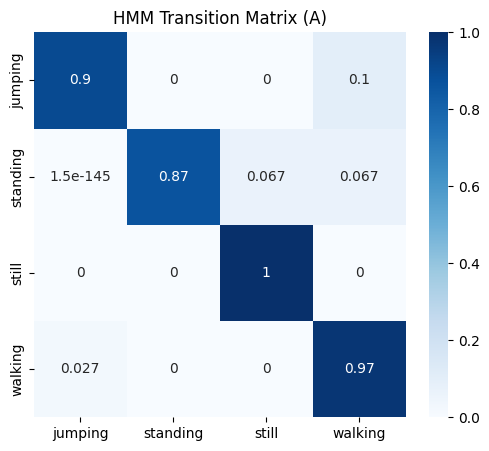

In [31]:
# Transition Matrix Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    A,
    annot=True,
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("HMM Transition Matrix (A)")
plt.show()

## PHASE 4: VITERBI IMPLEMENTATION

In [32]:
# Viterbi Algorithm
def viterbi(model, X):

    n_states = model.n_components
    n_samples = len(X)

    log_prob = np.zeros((n_samples, n_states))
    backpointer = np.zeros((n_samples, n_states), dtype=int)

    # Initial step
    for s in range(n_states):
        log_prob[0, s] = np.log(model.startprob_[s]) + model._compute_log_likelihood(X)[0, s]

    # Recursion
    for t in range(1, n_samples):

        for s in range(n_states):

            seq_probs = log_prob[t-1] + np.log(model.transmat_[:, s])

            best_prev = np.argmax(seq_probs)

            log_prob[t, s] = seq_probs[best_prev] + model._compute_log_likelihood(X)[t, s]

            backpointer[t, s] = best_prev

    # Backtracking
    states = np.zeros(n_samples, dtype=int)

    states[-1] = np.argmax(log_prob[-1])

    for t in range(n_samples-2, -1, -1):
        states[t] = backpointer[t+1, states[t+1]]

    return states

## PHASE 5/ EVALUATION

In [33]:
# Predict on Test Data
X_test = test_df.drop(columns=metadata_cols).values

y_test_true = le.transform(test_df["label"])

y_pred = viterbi(model, X_test)

/tmp/ipykernel_1510/166893643.py:19: RuntimeWarning: divide by zero encountered in log
  seq_probs = log_prob[t-1] + np.log(model.transmat_[:, s])


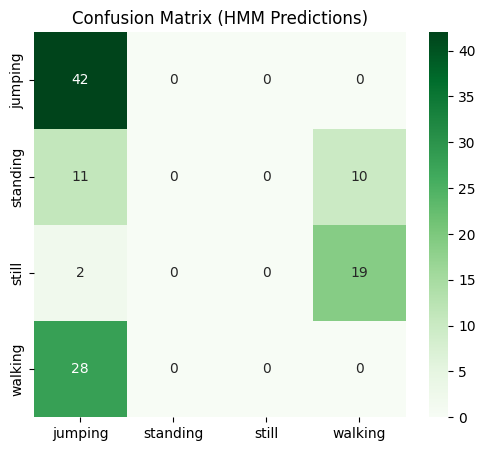

In [34]:
# Confusion Matrix
cm = confusion_matrix(y_test_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix (HMM Predictions)")
plt.show()

In [35]:
# Metrics (Sensitivity / Specificity / Accuracy)
def compute_metrics(cm):

    results = []

    for i in range(len(cm)):

        TP = cm[i,i]
        FN = sum(cm[i,:]) - TP
        FP = sum(cm[:,i]) - TP
        TN = cm.sum() - (TP + FN + FP)

        sensitivity = TP / (TP + FN + 1e-6)
        specificity = TN / (TN + FP + 1e-6)
        accuracy = (TP + TN) / cm.sum()

        results.append([TP+FN, sensitivity, specificity, accuracy])

    return results


metrics = compute_metrics(cm)

for i, cls in enumerate(le.classes_):

    print(f"\nClass: {cls}")
    print("Samples:", metrics[i][0])
    print("Sensitivity:", metrics[i][1])
    print("Specificity:", metrics[i][2])
    print("Accuracy:", metrics[i][3])


Class: jumping
Samples: 42
Sensitivity: 0.9999999761904769
Specificity: 0.414285708367347
Accuracy: 0.6339285714285714

Class: standing
Samples: 21
Sensitivity: 0.0
Specificity: 0.9999999890109892
Accuracy: 0.8125

Class: still
Samples: 21
Sensitivity: 0.0
Specificity: 0.9999999890109892
Accuracy: 0.8125

Class: walking
Samples: 28
Sensitivity: 0.0
Specificity: 0.6547618969671203
Accuracy: 0.49107142857142855


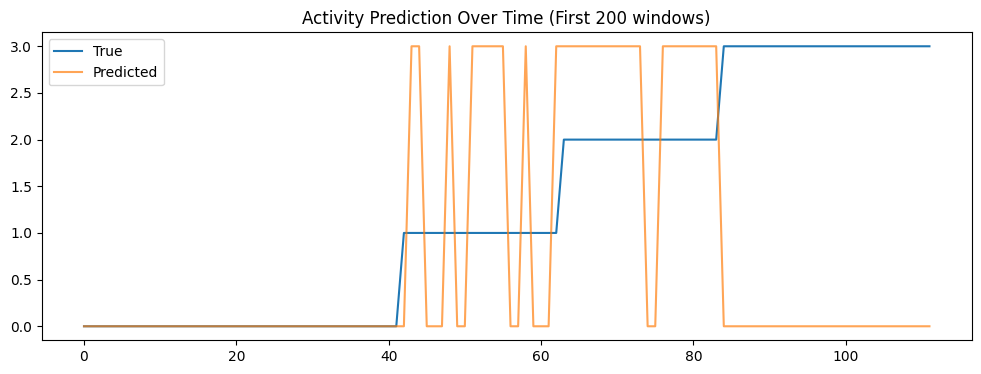

In [36]:
# Visualization — Predicted Activity Timeline
plt.figure(figsize=(12,4))

plt.plot(y_test_true[:200], label="True")
plt.plot(y_pred[:200], label="Predicted", alpha=0.7)

plt.legend()
plt.title("Activity Prediction Over Time (First 200 windows)")
plt.show()

/tmp/ipykernel_1510/3116265983.py:6: RuntimeWarning: invalid value encountered in divide
  pred_transitions = pred_transitions / pred_transitions.sum(axis=1, keepdims=True)


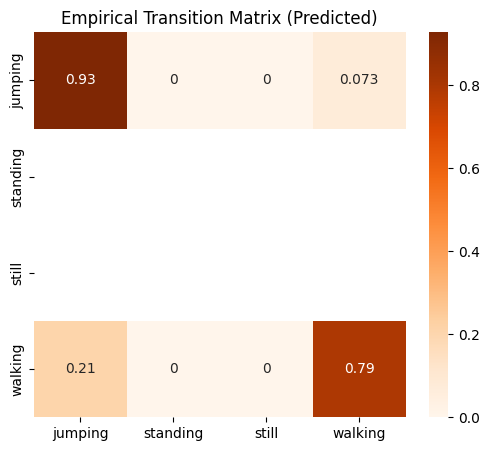

In [37]:
pred_transitions = np.zeros((4,4))

for i in range(len(y_pred)-1):
    pred_transitions[y_pred[i], y_pred[i+1]] += 1

pred_transitions = pred_transitions / pred_transitions.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))

sns.heatmap(
    pred_transitions,
    annot=True,
    cmap="Oranges",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Empirical Transition Matrix (Predicted)")
plt.show()

## Phase 6: Experiment II
- Added PCA for dimensionality or feature reduction
- Increased the n_iter to 500 for GaussianHMM
- Changed to covariance_type = 'full'

In [88]:
features_df = pd.read_csv("features.csv")

features_df.head()

,recording_id,window_id,label,acc_x_mean,acc_x_std,acc_x_var,acc_x_rms,acc_x_max,acc_x_min,acc_y_mean,...,gyro_z_rms,gyro_z_max,gyro_z_min,SMA,corr_xy,corr_xz,corr_yz,dominant_frequency,spectral_energy,fft_peak_magnitude
0,jumping_jumping_1,1,jumping,-0.788408,1.861957,1.842476,1.833559,2.270180,-1.726695,-0.217563,...,1.199637,1.937253,-1.607497,2.033004,-0.217903,-0.406446,1.744083,-0.444010,2.178416,2.200552
1,jumping_jumping_1,2,jumping,0.095927,1.953967,2.011160,1.917115,2.270180,-2.271134,-0.311558,...,0.624086,1.159050,-1.226042,2.472612,-0.343043,-1.078537,1.726556,0.218909,3.224712,2.252686
2,jumping_jumping_1,3,jumping,-0.101653,1.671309,1.511210,1.635715,1.808065,-2.271134,4.345289,...,0.310523,1.035764,-0.821293,2.356221,-0.215052,-1.425780,1.529945,-0.046259,3.315572,2.427324
3,jumping_jumping_1,4,jumping,-0.336093,1.278756,0.906665,1.246366,1.808065,-0.735574,4.755784,...,0.173324,1.035764,-0.170997,2.362415,-0.797156,-1.799933,1.508658,-0.046259,3.364640,2.382659
4,jumping_jumping_1,5,jumping,-0.995007,1.153821,0.736160,1.136248,0.926502,-1.620772,0.395726,...,-0.076924,0.639601,-0.235314,2.289213,0.784586,-0.055748,1.669180,-0.046259,3.230854,2.206697


In [89]:
def add_advanced_features(df_window):

    acc = df_window[["x_acc", "y_acc", "z_acc"]].values

    gyro = df_window[["x_gyro", "y_gyro", "z_gyro"]].values

    # 1. Magnitude
    acc_mag = np.sqrt((acc**2).sum(axis=1))

    # 2. Jerk (change in acceleration)
    jerk = np.diff(acc_mag, prepend=acc_mag[0])

    # 3. Energy
    energy = np.mean(acc_mag**2)

    # 4. Log energy (VERY IMPORTANT for separating still/walking)
    log_energy = np.log(energy + 1e-6)

    return {
        "acc_mag_mean": np.mean(acc_mag),
        "acc_mag_std": np.std(acc_mag),
        "jerk_mean": np.mean(jerk),
        "energy": energy,
        "log_energy": log_energy
    }

In [90]:
# Apply pca
X = features_df.drop(columns=["label", "recording_id", "window_id"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)

print("Original dims:", X.shape)
print("PCA dims:", X_pca.shape)

Original dims: (364, 43)
PCA dims: (364, 10)


In [91]:
X_test = test_df.drop(columns=metadata_cols).values

X_test_scaled = scaler.transform(X_test)   # IMPORTANT: transform only
X_test_pca = pca.transform(X_test_scaled)  # SAME PCA

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [92]:
kmeans = KMeans(n_clusters=4, random_state=42)
init_states = kmeans.fit_predict(X_pca)

model = GaussianHMM(
    n_components=4,
    covariance_type="full",   # MUCH more stable than "full"
    n_iter=500,
    init_params="stmc",       # allow full learning
    random_state=30
)

In [93]:
model.startprob_ = np.ones(4) / 4

model.transmat_ = np.array([
    [0.6, 0.2, 0.1, 0.1],
    [0.2, 0.6, 0.1, 0.1],
    [0.1, 0.2, 0.6, 0.1],
    [0.1, 0.1, 0.2, 0.6],
])

In [94]:
lengths = df.groupby("recording_id").size().tolist()

In [95]:
model.fit(X_pca, lengths)

GaussianHMM(covariance_type='full', n_components=4, n_iter=500, random_state=30)

In [96]:
# Extract HMM Components (for report)
A = model.transmat_      # transition probabilities
pi = model.startprob_    # initial probabilities

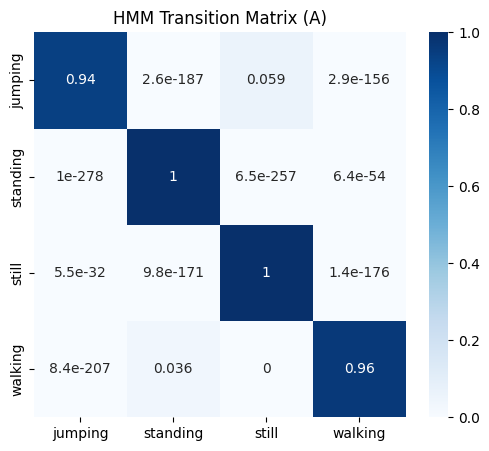

In [97]:
# Transition Matrix Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    A,
    annot=True,
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("HMM Transition Matrix (A)")
plt.show()

In [98]:
# Viterbi Algorithm
def viterbi(model, X):

    n_states = model.n_components
    n_samples = len(X)

    log_prob = np.zeros((n_samples, n_states))
    backpointer = np.zeros((n_samples, n_states), dtype=int)

    # Initial step
    for s in range(n_states):
        log_prob[0, s] = np.log(model.startprob_[s]) + model._compute_log_likelihood(X)[0, s]

    # Recursion
    for t in range(1, n_samples):

        for s in range(n_states):

            seq_probs = log_prob[t-1] + np.log(model.transmat_[:, s])

            best_prev = np.argmax(seq_probs)

            log_prob[t, s] = seq_probs[best_prev] + model._compute_log_likelihood(X)[t, s]

            backpointer[t, s] = best_prev

    # Backtracking
    states = np.zeros(n_samples, dtype=int)

    states[-1] = np.argmax(log_prob[-1])

    for t in range(n_samples-2, -1, -1):
        states[t] = backpointer[t+1, states[t+1]]

    return states

In [99]:
# Predict on Test Data
X_test = test_df.drop(columns=metadata_cols).values

y_test_true = le.transform(test_df["label"])

y_pred = viterbi(model, X_test_pca)

/tmp/ipykernel_1510/166893643.py:19: RuntimeWarning: divide by zero encountered in log
  seq_probs = log_prob[t-1] + np.log(model.transmat_[:, s])


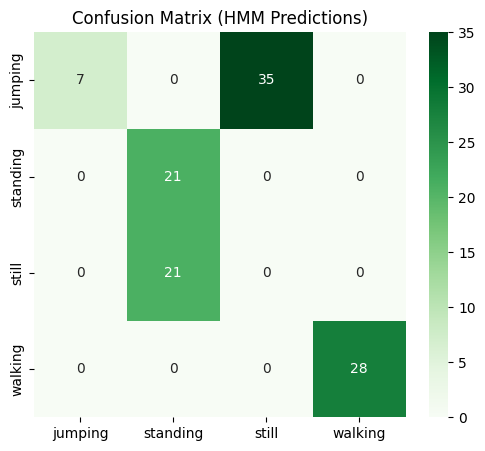

In [100]:
# Confusion Matrix
cm = confusion_matrix(y_test_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix (HMM Predictions)")
plt.show()

In [101]:
# Metrics (Sensitivity / Specificity / Accuracy)
def compute_metrics(cm):

    results = []

    for i in range(len(cm)):

        TP = cm[i,i]
        FN = sum(cm[i,:]) - TP
        FP = sum(cm[:,i]) - TP
        TN = cm.sum() - (TP + FN + FP)

        sensitivity = TP / (TP + FN + 1e-6)
        specificity = TN / (TN + FP + 1e-6)
        accuracy = (TP + TN) / cm.sum()

        results.append([TP+FN, sensitivity, specificity, accuracy])

    return results


metrics = compute_metrics(cm)

for i, cls in enumerate(le.classes_):

    print(f"\nClass: {cls}")
    print("Samples:", metrics[i][0])
    print("Sensitivity:", metrics[i][1])
    print("Specificity:", metrics[i][2])
    print("Accuracy:", metrics[i][3])


Class: jumping
Samples: 42
Sensitivity: 0.1666666626984128
Specificity: 0.9999999857142859
Accuracy: 0.6875

Class: standing
Samples: 21
Sensitivity: 0.9999999523809546
Specificity: 0.7692307607776839
Accuracy: 0.8125

Class: still
Samples: 21
Sensitivity: 0.0
Specificity: 0.6153846086221472
Accuracy: 0.5

Class: walking
Samples: 28
Sensitivity: 0.9999999642857155
Specificity: 0.9999999880952383
Accuracy: 1.0


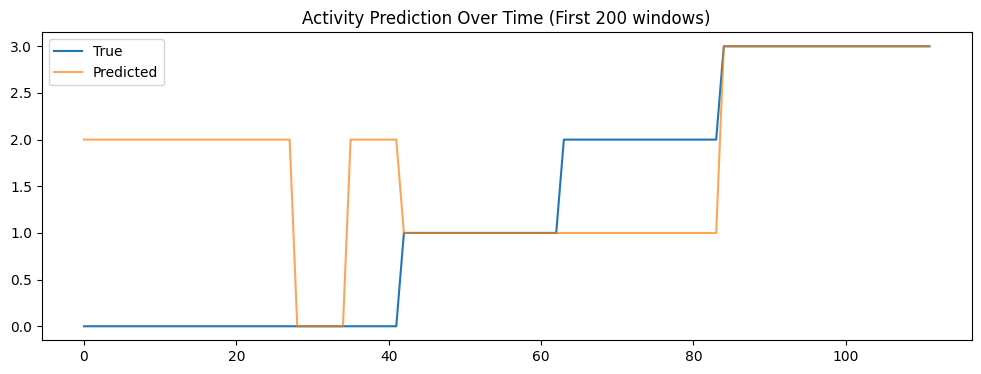

In [102]:
# Visualization — Predicted Activity Timeline
plt.figure(figsize=(12,4))

plt.plot(y_test_true[:200], label="True")
plt.plot(y_pred[:200], label="Predicted", alpha=0.7)

plt.legend()
plt.title("Activity Prediction Over Time (First 200 windows)")
plt.show()

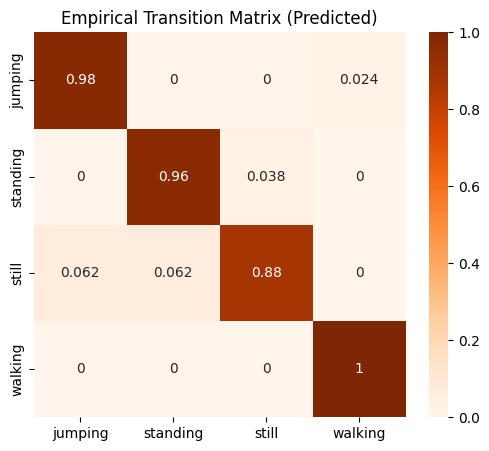

In [73]:
pred_transitions = np.zeros((4,4))

for i in range(len(y_pred)-1):
    pred_transitions[y_pred[i], y_pred[i+1]] += 1

pred_transitions = pred_transitions / pred_transitions.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))

sns.heatmap(
    pred_transitions,
    annot=True,
    cmap="Oranges",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Empirical Transition Matrix (Predicted)")
plt.show()